# Propensity Score Matching — Right Heart Catheterization

Replicates the Connors et al. (1996) analysis of whether right heart catheterization (RHC)
affects 30-day survival in critically ill ICU patients.

| | |
|---|---|
| **Treatment** | `received_rhc` — received RHC on day 1 of ICU admission (0/1) |
| **Outcome** | `died_30day` — died within 30 days of admission (0/1) |
| **Sample** | 5,735 critically ill patients |
| **Source** | Connors et al., JAMA 1996; data via hbiostat.org |

**The famous result:** RHC was standard clinical practice but PSM showed it was associated with
*increased* mortality — a finding that changed ICU care worldwide.

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [100]:
DATA_DIR = Path("../data/raw")

df = pd.read_csv(DATA_DIR / "rhc.csv", index_col=0)

df = df.rename(columns={
    # --- Treatment & Outcome ---
    "swang1":    "received_rhc",                    # treatment: RHC on day 1 (RHC / No RHC)
    "death":     "died_180day",                     # death at any time up to 180 days (Yes/No)
    "dth30":     "died_30day",                      # death within 30 days — primary outcome (Yes/No)

    # --- Dates ---
    "sadmdte":   "study_admission_date",            # date patient entered the study
    "dschdte":   "hospital_discharge_date",         # date of hospital discharge
    "dthdte":    "date_of_death",                   # date of death (if applicable)
    "lstctdte":  "last_contact_date",               # date of last known contact
    "ptid":      "patient_id",                      # unique patient identifier

    # --- Demographics ---
    "age":       "age_years",                       # age at admission
    "sex":       "sex",                             # sex (Male / Female)
    "race":      "race",                            # race (white / black / other)
    "edu":       "education_years",                 # years of formal education
    "income":    "income",                          # income bracket
    "ninsclas":  "insurance_class",                 # insurance type (Medicare/Medicaid/Private etc.)

    # --- Disease categories ---
    "cat1":      "primary_disease_category",        # primary diagnosis category on admission
    "cat2":      "secondary_disease_category",      # secondary diagnosis category on admission
    "ca":        "cancer_status",                   # cancer diagnosis (No / Yes / Metastatic)

    # --- Admission reason indicators (binary) ---
    "resp":      "admission_respiratory",           # respiratory disease as admission reason
    "card":      "admission_cardiac",               # cardiovascular disease as admission reason
    "neuro":     "admission_neurological",          # neurological disease as admission reason
    "gastr":     "admission_gastrointestinal",      # GI disease as admission reason
    "renal":     "admission_renal",                 # renal disease as admission reason
    "meta":      "admission_metabolic",             # metabolic disease as admission reason
    "hema":      "admission_hematological",         # hematological disease as admission reason
    "seps":      "admission_sepsis",                # sepsis as admission reason
    "trauma":    "admission_trauma",                # trauma as admission reason
    "ortho":     "admission_orthopedic",            # orthopedic condition as admission reason

    # --- Medical history / comorbidities (binary 0/1) ---
    "cardiohx":  "hx_cardiac_disease",             # history of cardiac disease
    "chfhx":     "hx_congestive_heart_failure",    # history of congestive heart failure
    "dementhx":  "hx_dementia",                    # history of dementia
    "psychhx":   "hx_psychiatric_disorder",        # history of psychiatric disorder
    "chrpulhx":  "hx_chronic_pulmonary_disease",   # history of chronic pulmonary disease
    "renalhx":   "hx_renal_disease",               # history of renal disease
    "liverhx":   "hx_liver_disease",               # history of liver disease
    "gibledhx":  "hx_gi_bleeding",                 # history of GI bleeding
    "malighx":   "hx_malignancy",                  # history of malignancy
    "immunhx":   "hx_immunosuppression",           # history of immunosuppression
    "transhx":   "hx_prior_transplant",            # history of prior transplant
    "amihx":     "hx_acute_myocardial_infarction", # history of acute MI

    # --- Functional status ---
    "adld3p":    "activities_daily_living_prior",  # ADL score 3 days before admission
    "das2d3pc":  "duke_activity_status_index",     # DASI score 2 days before admission
    "dnr1":      "dnr_status_day1",                # do-not-resuscitate order on day 1 (Yes/No)

    # --- Severity scores ---
    "aps1":      "apache_score_day1",              # APACHE III severity score on day 1
    "scoma1":    "glasgow_coma_score_day1",        # Glasgow Coma Scale score on day 1
    "surv2md1":  "support_2month_survival_prob",   # SUPPORT model predicted 2-month survival
    "t3d30":     "support_survival_time_30day",    # SUPPORT model predicted survival time (30-day)

    # --- Vital signs on day 1 ---
    "meanbp1":   "mean_blood_pressure_day1",       # mean arterial blood pressure (mmHg)
    "hrt1":      "heart_rate_day1",                # heart rate (beats per minute)
    "resp1":     "respiratory_rate_day1",          # respiratory rate (breaths per minute)
    "temp1":     "temperature_celsius_day1",       # body temperature (Celsius)
    "wtkilo1":   "weight_kg_day1",                 # body weight (kg)

    # --- Lab values on day 1 ---
    "pafi1":     "pao2_fio2_ratio_day1",           # PaO2/FiO2 ratio — measure of oxygenation
    "paco21":    "paco2_day1",                     # arterial CO2 partial pressure (mmHg)
    "ph1":       "blood_ph_day1",                  # arterial blood pH
    "wblc1":     "white_blood_cell_count_day1",    # WBC count (thousands per mm³)
    "hema1":     "hematocrit_day1",                # hematocrit (%)
    "sod1":      "sodium_day1",                    # serum sodium (mEq/L)
    "pot1":      "potassium_day1",                 # serum potassium (mEq/L)
    "crea1":     "creatinine_day1",                # serum creatinine (mg/dL)
    "bili1":     "bilirubin_day1",                 # serum bilirubin (mg/dL)
    "alb1":      "albumin_day1",                   # serum albumin (g/dL)
    "urin1":     "urine_output_day1",              # urine output (mL)
})

# Convert all Yes/No string columns to binary integers
for col in ["received_rhc", "died_30day", "died_180day"]:
    df[col] = (df[col].isin(["RHC", "Yes"])).astype(int)

print(f"Shape: {df.shape}")
print(f"Received RHC  : {df.received_rhc.sum():,}")
print(f"No RHC        : {(df.received_rhc == 0).sum():,}")
print(f"\nDied (30 day) : {df.died_30day.sum():,}  ({df.died_30day.mean():.1%})")
print(f"Died (180 day): {df.died_180day.sum():,} ({df.died_180day.mean():.1%})")

Shape: (5735, 62)
Received RHC  : 2,184
No RHC        : 3,551

Died (30 day) : 1,918  (33.4%)
Died (180 day): 3,722 (64.9%)


In [101]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
study_admission_date,5735.0,11638.686312,513.967751,10754.000000,11163.500000,11759.000000,12097.000000,12441.000000
hospital_discharge_date,5734.0,11660.050401,513.447322,10757.000000,11184.000000,11777.000000,12120.000000,12560.000000
date_of_death,3722.0,11753.869156,538.812330,10757.000000,11267.000000,11831.500000,12208.000000,12783.000000
last_contact_date,5735.0,11781.257890,524.094168,10756.000000,11316.000000,11868.000000,12244.000000,12644.000000
died_180day,5735.0,0.648997,0.477325,0.000000,0.000000,1.000000,1.000000,1.000000
hx_cardiac_disease,5735.0,0.176635,0.381393,0.000000,0.000000,0.000000,0.000000,1.000000
hx_congestive_heart_failure,5735.0,0.178030,0.382571,0.000000,0.000000,0.000000,0.000000,1.000000
hx_dementia,5735.0,0.098344,0.297805,0.000000,0.000000,0.000000,0.000000,1.000000
hx_psychiatric_disorder,5735.0,0.067306,0.250573,0.000000,0.000000,0.000000,0.000000,1.000000
hx_chronic_pulmonary_disease,5735.0,0.189887,0.392246,0.000000,0.000000,0.000000,0.000000,1.000000


In [102]:
import re

## Encode categorical columns

# --- Binary Yes/No → 0/1 ---
yes_no_cols = [
    'dnr_status_day1',
    'admission_respiratory', 'admission_cardiac', 'admission_neurological',
    'admission_gastrointestinal', 'admission_renal', 'admission_metabolic',
    'admission_hematological', 'admission_sepsis', 'admission_trauma', 'admission_orthopedic',
]
for col in yes_no_cols:
    df[col] = (df[col] == 'Yes').astype(int)

# --- Sex: Female=1, Male=0 ---
df['sex'] = (df['sex'] == 'Female').astype(int)

# --- Multi-category columns: one-hot encode, drop first level to avoid dummy variable trap ---
multi_cat_cols = ['race', 'income', 'insurance_class', 'primary_disease_category', 'cancer_status']
df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True, dtype=int)

# Clean all column names so they're valid Python identifiers (no spaces, $, &, /, > etc.)
# This lets us use them directly in statsmodels formula strings without Q() wrapping
def clean_col(name):
    name = name.replace('&', 'and').replace('>', 'over').replace('$', '')
    return re.sub(r'_+', '_', re.sub(r'[^a-zA-Z0-9_]', '_', name)).strip('_')

df.columns = [clean_col(c) for c in df.columns]

new_dummy_cols = [c for c in df.columns if any(c.startswith(m + '_') for m in multi_cat_cols)]
print("New dummy columns created:")
for c in new_dummy_cols:
    print(f"  {c}")

New dummy columns created:
  race_other
  race_white
  income_25_50k
  income_over_50k
  income_Under_11k
  insurance_class_Medicare
  insurance_class_Medicare_and_Medicaid
  insurance_class_No_insurance
  insurance_class_Private
  insurance_class_Private_and_Medicare
  primary_disease_category_CHF
  primary_disease_category_COPD
  primary_disease_category_Cirrhosis
  primary_disease_category_Colon_Cancer
  primary_disease_category_Coma
  primary_disease_category_Lung_Cancer
  primary_disease_category_MOSF_w_Malignancy
  primary_disease_category_MOSF_w_Sepsis
  cancer_status_No
  cancer_status_Yes


In [103]:
TREATMENT = 'received_rhc'
OUTCOME   = 'died_30day'

COVARIATES = [
    # --- Comorbidities / medical history (binary 0/1) ---
    'hx_cardiac_disease',
    'hx_congestive_heart_failure',
    'hx_dementia',
    'hx_psychiatric_disorder',
    'hx_chronic_pulmonary_disease',
    'hx_renal_disease',
    'hx_liver_disease',
    'hx_gi_bleeding',
    'hx_malignancy',
    'hx_immunosuppression',
    'hx_prior_transplant',
    'hx_acute_myocardial_infarction',

    # --- Demographics ---
    'age_years',
    'sex',                          # Female=1, Male=0
    'education_years',

    # --- Disease severity ---
    'apache_score_day1',
    'glasgow_coma_score_day1',
    'support_2month_survival_prob',
    'dnr_status_day1',              # Yes=1, No=0

    # --- Vital signs on day 1 ---
    'mean_blood_pressure_day1',
    'heart_rate_day1',
    'respiratory_rate_day1',
    'temperature_celsius_day1',
    'weight_kg_day1',

    # --- Lab values on day 1 ---
    'pao2_fio2_ratio_day1',
    'paco2_day1',
    'blood_ph_day1',
    'white_blood_cell_count_day1',
    'hematocrit_day1',
    'sodium_day1',
    'potassium_day1',
    'creatinine_day1',
    'bilirubin_day1',
    'albumin_day1',


    # --- Functional status ---
    'duke_activity_status_index',

    # --- Admission reason flags (Yes=1, No=0) ---
    'admission_respiratory',
    'admission_cardiac',
    'admission_neurological',
    'admission_gastrointestinal',
    'admission_renal',
    'admission_metabolic',
    'admission_hematological',
    'admission_sepsis',
    'admission_trauma',
    'admission_orthopedic',
]

# Dynamically add all dummy columns created by one-hot encoding
multi_cat_prefixes = ['race_', 'income_', 'insurance_class_', 'primary_disease_category_', 'cancer_status_']
dummy_cols = [c for c in df.columns if any(c.startswith(p) for p in multi_cat_prefixes)]
COVARIATES = COVARIATES + dummy_cols

print(f"Treatment : {TREATMENT}")
print(f"Outcome   : {OUTCOME}")
print(f"Covariates: {len(COVARIATES)} ({len(dummy_cols)} are one-hot dummies)")

Treatment : received_rhc
Outcome   : died_30day
Covariates: 65 (20 are one-hot dummies)


In [104]:
df.groupby(TREATMENT)[OUTCOME].mean()

received_rhc
0    0.306393
1    0.380037
Name: died_30day, dtype: float64

In [105]:
missing = df[COVARIATES].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f"Covariates with missing values ({len(missing)} of {len(COVARIATES)}):")
print(missing.to_string())

Covariates with missing values (0 of 65):
Series([], )


In [106]:
def smd(df, covariates, treatment):
    """
    Compute standardized mean differences for a list of covariates.

    For each covariate, calculates:
        SMD = (mean_treated - mean_control) / pooled_SD

    where pooled_SD = sqrt((var_treated + var_control) / 2)

    Returns a DataFrame with one row per covariate showing the group means and SMD.
    """
    treated = df[df[treatment] == 1]
    control = df[df[treatment] == 0]
    rows = []

    for col in covariates:
        mt = treated[col].mean()
        mc = control[col].mean()
        pooled_sd = np.sqrt((treated[col].var() + control[col].var()) / 2)
        smd_val = (mt - mc) / pooled_sd if pooled_sd > 0 else np.nan
        rows.append({"covariate": col, "mean_treated": mt, "mean_control": mc, "smd": smd_val})

    return pd.DataFrame(rows).set_index("covariate").sort_values("smd", key=abs, ascending=False)

balance_pre = smd(df, COVARIATES, TREATMENT)
balance_pre

,mean_treated,mean_control,smd
covariate,,,
apache_score_day1,60.739011,50.933540,0.501402
mean_blood_pressure_day1,68.197802,84.868629,-0.455096
pao2_fio2_ratio_day1,192.433403,240.626632,-0.433242
primary_disease_category_MOSF_w_Sepsis,0.320513,0.148409,0.414797
admission_neurological,0.054029,0.161926,-0.352976
...,...,...,...
admission_orthopedic,0.001832,0.000845,0.026987
temperature_celsius_day1,37.594735,37.632885,-0.021371
race_other,0.065018,0.059983,0.020799


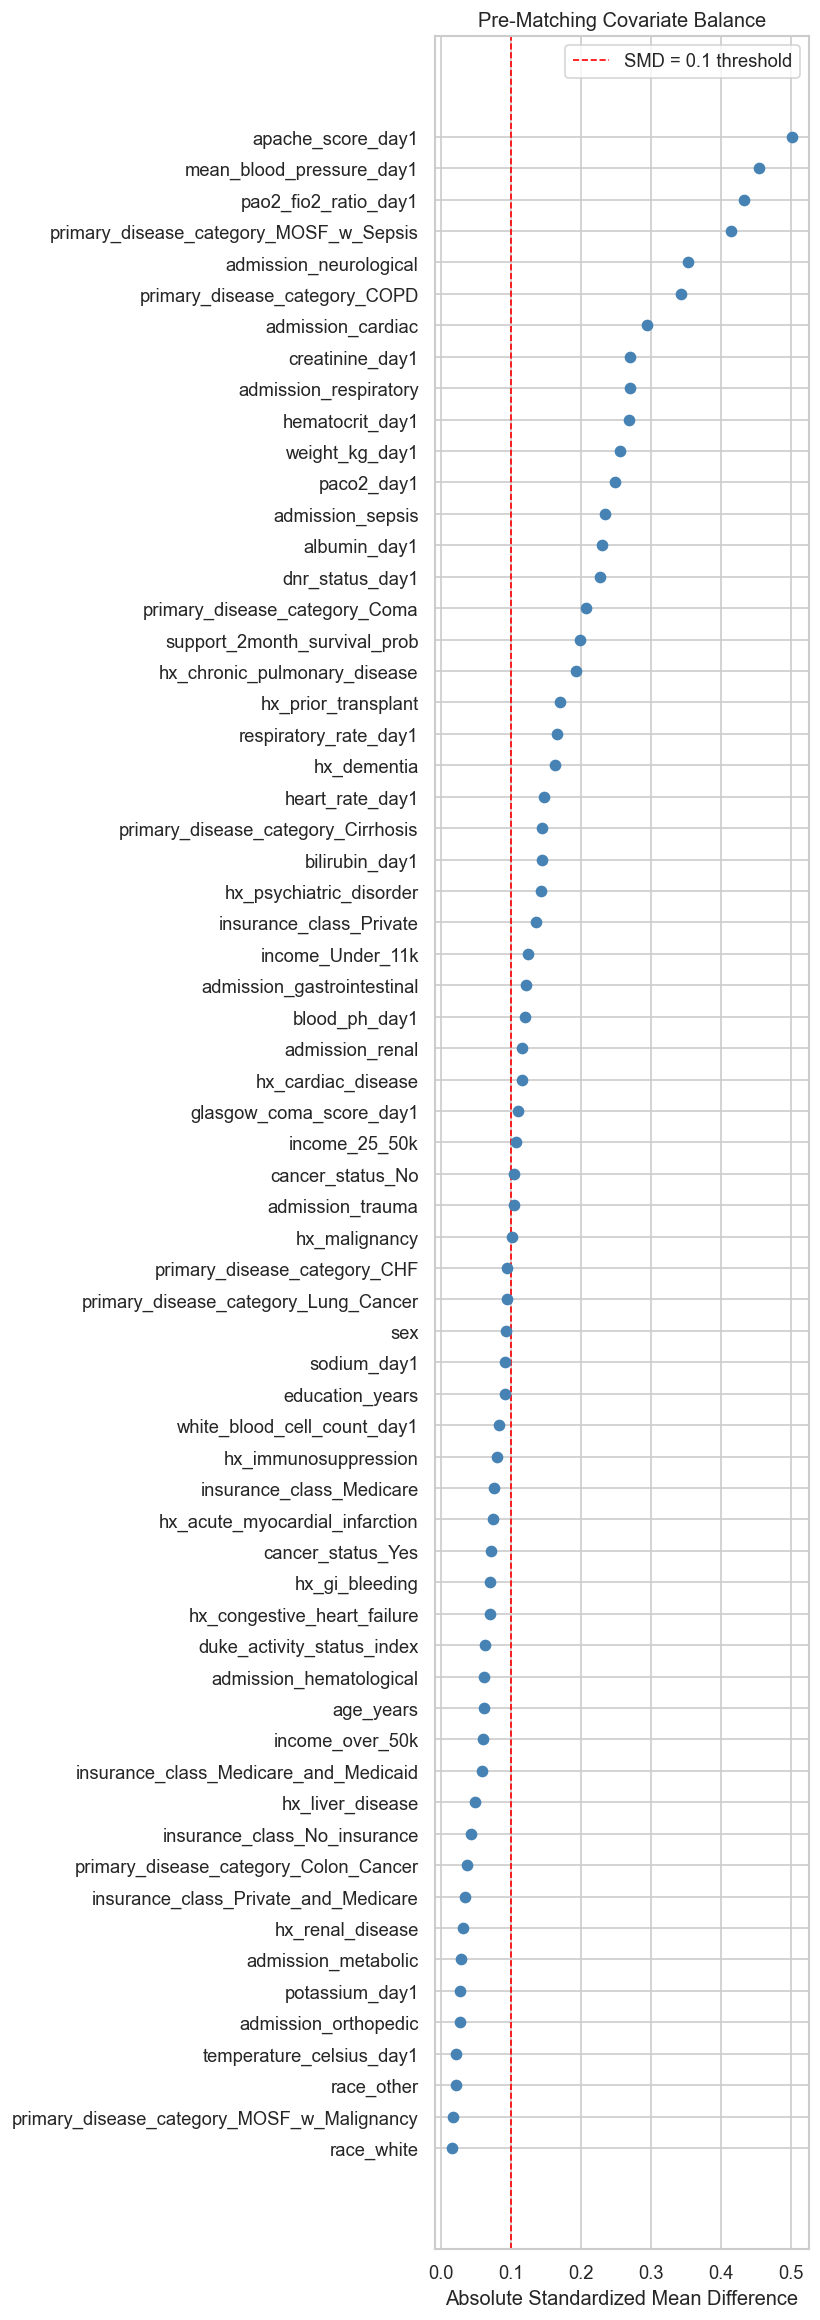

In [107]:
fig, ax = plt.subplots(figsize=(7, len(COVARIATES) * 0.3))

abs_smd = balance_pre["smd"].abs().sort_values()

ax.scatter(abs_smd.values, abs_smd.index, color="steelblue", zorder=3)
ax.axvline(0.1, color="red", linestyle="--", linewidth=1, label="SMD = 0.1 threshold")
ax.set_xlabel("Absolute Standardized Mean Difference")
ax.set_title("Pre-Matching Covariate Balance")
ax.legend()
plt.tight_layout()
plt.savefig('love_plot.png')

In [108]:
abs_smd.nlargest(30)

covariate
apache_score_day1                         0.501402
mean_blood_pressure_day1                  0.455096
pao2_fio2_ratio_day1                      0.433242
primary_disease_category_MOSF_w_Sepsis    0.414797
admission_neurological                    0.352976
primary_disease_category_COPD             0.342364
admission_cardiac                         0.294929
creatinine_day1                           0.269624
admission_respiratory                     0.269513
hematocrit_day1                           0.269301
weight_kg_day1                            0.255679
paco2_day1                                0.248594
admission_sepsis                          0.233797
albumin_day1                              0.229920
dnr_status_day1                           0.227600
primary_disease_category_Coma             0.207278
support_2month_survival_prob              0.198498
hx_chronic_pulmonary_disease              0.192322
hx_prior_transplant                       0.169784
respiratory_rate_day1

In [109]:
TREATMENT


'received_rhc'

In [110]:
formula = f"{TREATMENT} ~ {' + '.join(COVARIATES)}"

ps_model = smf.logit(formula, data=df).fit()
ps_model.summary()

Optimization terminated successfully.
         Current function value: 0.522512
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:           received_rhc   No. Observations:                 5735
Model:                          Logit   Df Residuals:                     5669
Method:                           MLE   Df Model:                           65
Date:                Mon, 29 Jun 2026   Pseudo R-squ.:                  0.2136
Time:                        21:01:53   Log-Likelihood:                -2996.6
converged:                       True   LL-Null:                       -3810.7
Covariance Type:            nonrobust   LLR p-value:                3.032e-297
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     17.2682      3.119      5.537      0.000      11.155      23.381
hx_cardiac_disease                             0.0483      0.095      0.506      0.613      -0.139       0.235
hx_congestive_heart_failure                    0.0937      0.104      0.898      0.369      -0.111       0.298
hx_dementia                                   -0.4122      0.121     -3.397      0.001      -0.650      -0.174
hx_psychiatric_disorder                       -0.3913      0.138     -2.831      0.005      -0.662      -0.120
hx_chronic_pulmonary_disease                   0.0122      0.101      0.122      0.903      -0.185       0.210
hx_renal_disease                              -0.3353      0.181     -1.848      0.065      -0.691       0.020
hx_liver_disease                              -0.0410      0.188     -0.218      0.827      -0.409       0.327
hx_gi_bleeding                                -0.1856      0.228     -0.813      0.416      -0.633       0.262
hx_malignancy                                  0.2298      0.385      0.598      0.550      -0.524       0.984
hx_immunosuppression                           0.0454      0.074      0.612      0.541      -0.100       0.191
hx_prior_transplant                            0.4717      0.099      4.744      0.000       0.277       0.667
hx_acute_myocardial_infarction                 0.1318      0.175      0.753      0.451      -0.211       0.475
age_years                                     -0.0044      0.003     -1.528      0.126      -0.010       0.001
sex                                           -0.0478      0.068     -0.704      0.481      -0.181       0.085
education_years                                0.0262      0.012      2.240      0.025       0.003       0.049
apache_score_day1                              0.0038      0.003      1.279      0.201      -0.002       0.010
glasgow_coma_score_day1                       -0.0042      0.002     -2.597      0.009      -0.007      -0.001
support_2month_survival_prob                  -1.8855      0.354     -5.333      0.000      -2.578      -1.193
dnr_status_day1                               -0.6778      0.117     -5.810      0.000      -0.906      -0.449
mean_blood_pressure_day1                      -0.0064      0.001     -6.226      0.000      -0.008      -0.004
heart_rate_day1                                0.0055      0.001      6.108      0.000       0.004       0.007
respiratory_rate_day1                         -0.0208      0.003     -8.002      0.000      -0.026      -0.016
temperature_celsius_day1                      -0.0285      0.020     -1.440      0.150      -0.067       0.010
weight_kg_day1                                 0.0063      0.001      5.203      0.000       0.004       0.009
pao2_fio2_ratio_day1                          -0.0047      0.000    -13.639      0.000      -0.005      -0.004
paco2_day1            

In [111]:
# Extract predicted probabilities from the fitted model and store on the dataframe.
# model.predict() with no arguments uses the same data the model was fitted on.
# The output is each person's estimated probability of having quit smoking,
# given their observed covariates — this is their propensity score.
df["propensity_score"] = ps_model.predict()

# Summarise the score distribution separately for each group.
# We want to see: (1) do the means differ? (2) how wide is each distribution?
# A well-fitted model should assign higher scores to quitters on average.
df.groupby(TREATMENT)["propensity_score"].describe()

,count,mean,std,min,25%,50%,75%,max
received_rhc,,,,,,,,
0,3551.0,0.283250,0.207088,0.002741,0.106298,0.236485,0.421398,0.960766
1,2184.0,0.539459,0.221314,0.019040,0.373606,0.556355,0.716552,0.978054


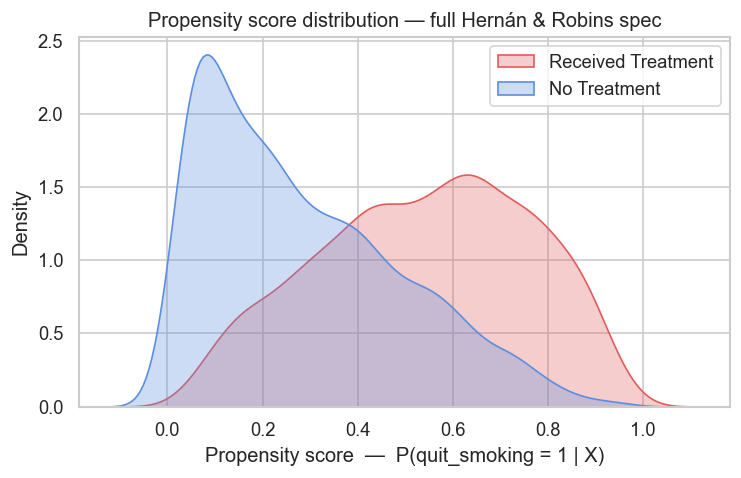

In [112]:
fig, ax = plt.subplots(figsize=(7, 4))

# Overlay KDE distributions for each group
# What we want to see: two overlapping but distinct humps — enough separation for scores
# to be doing useful work, enough overlap for valid matches to exist
for val, label, color in [(1, "Received Treatment", "#e05c5c"), (0, "No Treatment", "#5c8ee0")]:
    sns.kdeplot(df[df[TREATMENT] == val]["propensity_score"], ax=ax, label=label, color=color, fill=True, alpha=0.3)

ax.set_xlabel("Propensity score  —  P(quit_smoking = 1 | X)")
ax.set_title("Propensity score distribution — full Hernán & Robins spec")
ax.legend()
plt.show()

In [113]:
ps_treated = df[df[TREATMENT] == 1]["propensity_score"]
ps_control = df[df[TREATMENT] == 0]["propensity_score"]

# Common support = the intersection of both score ranges
# overlap_min: the highest minimum (below this, only controls exist)
# overlap_max: the lowest maximum (above this, only treated units exist)
overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print(f"Common support region: [{overlap_min:.3f}, {overlap_max:.3f}]")
print(f"Treated units outside common support: {(ps_treated > overlap_max).sum()} of {len(ps_treated)}")
print(f"\nThese units will be excluded from matching — no comparable control exists for them.")

Common support region: [0.019, 0.961]
Treated units outside common support: 5 of 2184

These units will be excluded from matching — no comparable control exists for them.


In [114]:
# Caliper = 0.2 × SD of the propensity score (Austin, 2011)
# This is computed on the full sample before trimming to common support
caliper = 0.2 * df["propensity_score"].std()

print(f"Propensity score SD : {df['propensity_score'].std():.4f}")
print(f"Caliper (0.2 × SD) : {caliper:.4f}")
print(f"\nScore range         : [{df['propensity_score'].min():.3f}, {df['propensity_score'].max():.3f}]")
print(f"Caliper as % of range: {caliper / (df['propensity_score'].max() - df['propensity_score'].min()) * 100:.1f}%")
print(f"\nA caliper of {caliper:.4f} means two units must be within ~{caliper:.3f} propensity score")
print(f"points of each other to be considered a valid match.")

Propensity score SD : 0.2463
Caliper (0.2 × SD) : 0.0493

Score range         : [0.003, 0.978]
Caliper as % of range: 5.1%

A caliper of 0.0493 means two units must be within ~0.049 propensity score
points of each other to be considered a valid match.


In [115]:
from sklearn.neighbors import NearestNeighbors

# Separate the two pools we are matching from.
# .copy() ensures modifications (like removing matched controls) don't affect df.
treated = df[df[TREATMENT] == 1].copy()  # the 403 quitters — each needs one match
control = df[df[TREATMENT] == 0].copy()  # the 1163 non-quitters — the matching pool

print(f"Treated pool (quitters)    : {len(treated)}")
print(f"Control pool (non-quitters): {len(control)}")
print(f"\nFor every treated we will find their nearest neighbour in the control pool.")
print(f"If the distance exceeds the caliper ({caliper:.4f}), the quitter is dropped.")

Treated pool (quitters)    : 2184
Control pool (non-quitters): 3551

For every treated we will find their nearest neighbour in the control pool.
If the distance exceeds the caliper (0.0493), the quitter is dropped.


In [116]:
# Build a nearest-neighbour index on the control pool's propensity scores.
# NearestNeighbors is not a predictive model — it's purely a distance calculator.
# n_neighbors=1 means we want exactly one match per treated unit (1-to-1 matching).
# Double brackets give a 2D DataFrame (1163, 1) — sklearn requires 2D array input,
# not a 1D Series which single brackets would produce.
nn = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn.fit(control[["propensity_score"]])

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [117]:
distances, indices = nn.kneighbors(treated[["propensity_score"]])

In [118]:
print(distances[:5])
print(indices[:5])

[[8.81596620e-05]
 [2.40158567e-04]
 [5.48814743e-04]
 [2.53314549e-06]
 [8.40001008e-04]]
[[2392]
 [1154]
 [2555]
 [3248]
 [3490]]


In [119]:
import random
random.seed(42)

treated_shuffled = treated.sample(frac=1, random_state=42)
available_control = control.copy()

matched_treated = []
matched_control = []
unmatched = 0

for _, t_row in treated_shuffled.iterrows():
    if available_control.empty:
        unmatched += 1
        continue

    # Rebuild index on remaining available controls
    nn_iter = NearestNeighbors(n_neighbors=1, metric="euclidean")
    nn_iter.fit(available_control[["propensity_score"]])

    dist, idx = nn_iter.kneighbors(pd.DataFrame({"propensity_score": [t_row["propensity_score"]]}))
    dist = dist[0][0]
    idx  = idx[0][0]

    if dist > caliper:
        unmatched += 1
        continue

    matched_row = available_control.iloc[idx]
    matched_treated.append(t_row)
    matched_control.append(matched_row)

    # Remove the matched control so it can't be reused
    available_control = available_control.drop(matched_row.name)

print(f"Matched pairs             : {len(matched_treated)}")
print(f"Dropped (caliper/no match): {unmatched}")

control_ids = [r.name for r in matched_control]
print(f"Unique controls used      : {len(set(control_ids))}")
print(f"Duplicates                : {len(control_ids) - len(set(control_ids))}")

Matched pairs             : 1553
Dropped (caliper/no match): 631
Unique controls used      : 1553
Duplicates                : 0


In [120]:
control_ids = [r.name for r in matched_control]
print(f"Total matches       : {len(control_ids)}")
print(f"Unique controls used: {len(set(control_ids))}")
print(f"Duplicates          : {len(control_ids) - len(set(control_ids))}")

Total matches       : 1553
Unique controls used: 1553
Duplicates          : 0


In [121]:
df_matched = pd.concat([
    pd.DataFrame(matched_treated),
    pd.DataFrame(matched_control)
], ignore_index=True)

print(f"Matched dataset shape: {df_matched.shape}")
print(f"Treated: {df_matched[TREATMENT].sum()}")
print(f"Control: {(df_matched[TREATMENT] == 0).sum()}")

Matched dataset shape: (3106, 78)
Treated: 1553
Control: 1553


In [122]:
balance_post = smd(df_matched, COVARIATES, TREATMENT)

In [123]:
treated_outcome = df[df[TREATMENT] == 1][OUTCOME]
control_outcome  = df[df[TREATMENT] == 0][OUTCOME]
naive_att = treated_outcome.mean() - control_outcome.mean()

matched_treated_outcome = df_matched[df_matched[TREATMENT] == 1][OUTCOME]
matched_control_outcome  = df_matched[df_matched[TREATMENT] == 0][OUTCOME]
att_matched = matched_treated_outcome.mean() - matched_control_outcome.mean()

print(f"Naive ATT (unadjusted) : {naive_att:.2f} survival rate")
print(f"PSM ATT (matched)      : {att_matched:.2f} survival rate")

Naive ATT (unadjusted) : 0.07 survival rate
PSM ATT (matched)      : 0.05 survival rate


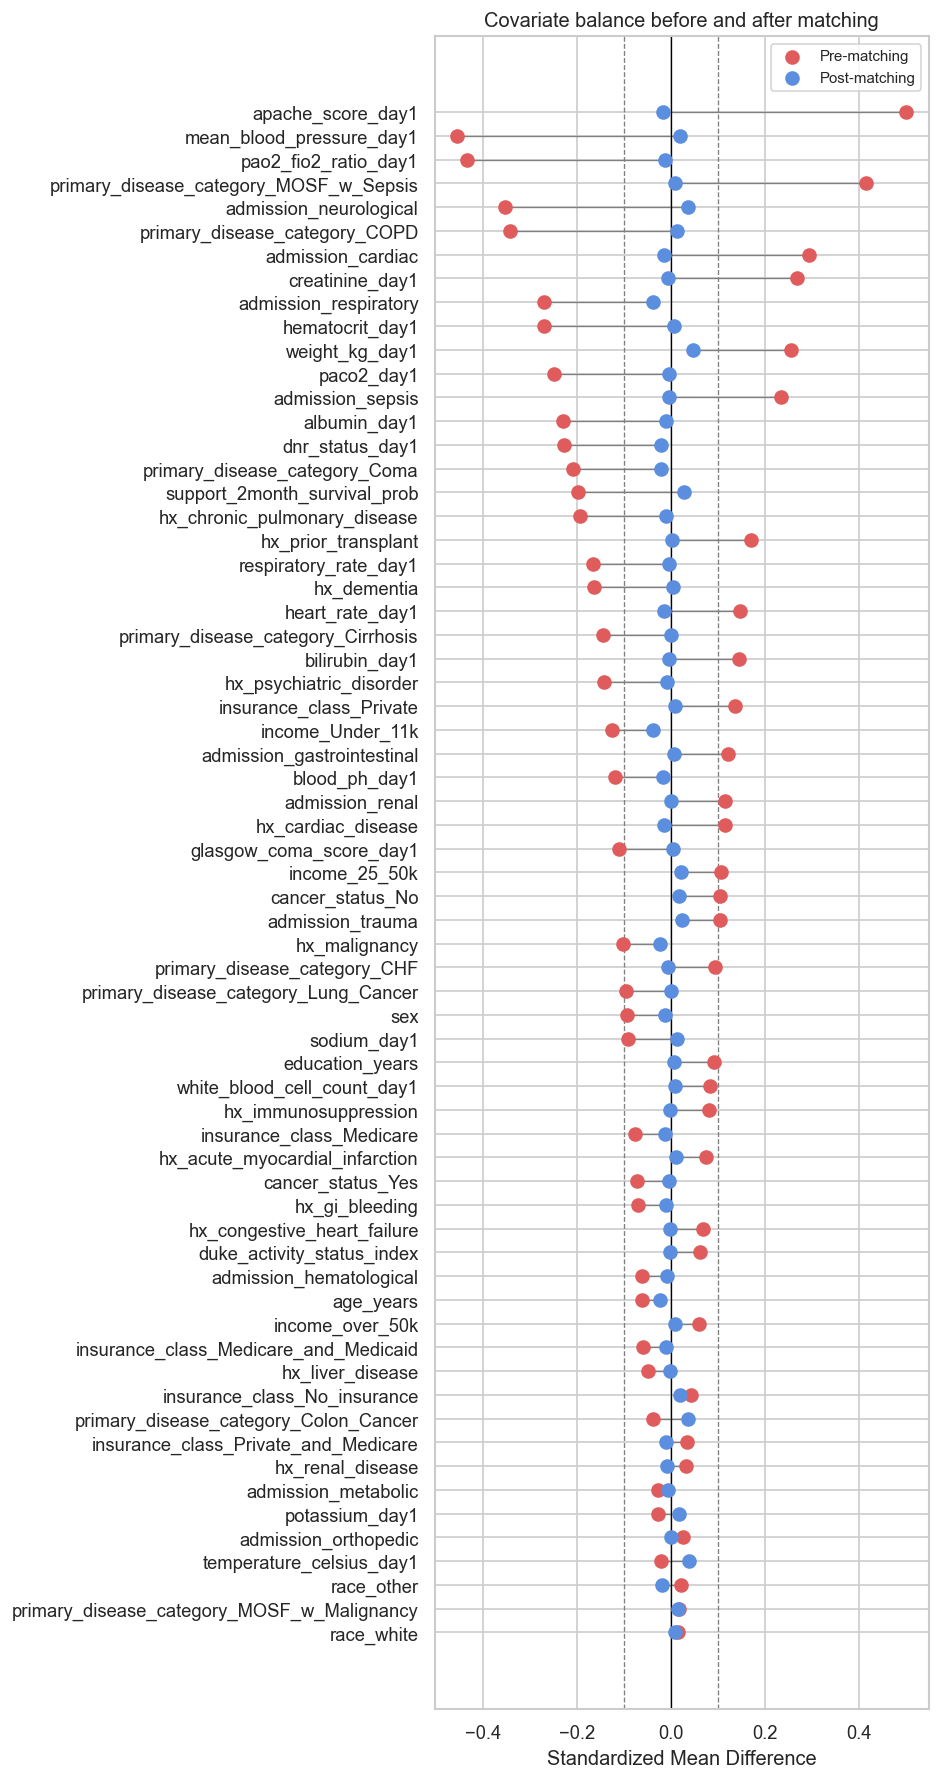

In [124]:
fig, ax = plt.subplots(figsize=(8, 15))

y_pos = range(len(COVARIATES))
covs  = balance_pre["smd"].sort_values(key=abs, ascending=True).index

pre  = balance_pre.loc[covs, "smd"]
post = balance_post.loc[covs, "smd"]

ax.scatter(pre,  y_pos, color="#e05c5c", zorder=3, s=60, label="Pre-matching")
ax.scatter(post, y_pos, color="#5c8ee0", zorder=3, s=60, label="Post-matching")

for i, cov in enumerate(covs):
    ax.plot([pre[cov], post[cov]], [i, i], color="grey", linewidth=0.8, zorder=2)

ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline(0.1,  color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")

ax.set_yticks(y_pos)
ax.set_yticklabels(covs)
ax.set_xlabel("Standardized Mean Difference")
ax.set_title("Covariate balance before and after matching")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [125]:
from scipy import stats

matched_treated_outcome = df_matched[df_matched[TREATMENT] == 1][OUTCOME].values
matched_control_outcome  = df_matched[df_matched[TREATMENT] == 0][OUTCOME].values

t_stat, p_val = stats.ttest_rel(matched_treated_outcome, matched_control_outcome)

att = matched_treated_outcome.mean() - matched_control_outcome.mean()
n   = len(matched_treated_outcome)
se  = (matched_treated_outcome - matched_control_outcome).std() / np.sqrt(n)
ci_low  = att - 1.96 * se
ci_high = att + 1.96 * se

print(f"ATT estimate : {att:.3f}  ({att*100:.1f} percentage points)")
print(f"95% CI       : [{ci_low:.3f}, {ci_high:.3f}]")
print(f"t-statistic  : {t_stat:.3f}")
print(f"p-value      : {p_val:.4f}")
print(f"\nMatched pairs: {n:,}")
print(f"\nInterpretation: RHC patients had a {att*100:.1f}pp higher 30-day mortality rate")
print(f"compared to matched non-RHC patients of similar severity.")

ATT estimate : 0.050  (5.0 percentage points)
95% CI       : [0.016, 0.084]
t-statistic  : 2.918
p-value      : 0.0036

Matched pairs: 1,553

Interpretation: RHC patients had a 5.0pp higher 30-day mortality rate
compared to matched non-RHC patients of similar severity.
